In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [4]:
df_index=pd.read_csv("Economics.csv")

In [5]:
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1200


In [8]:
## drop unneccary columns
df_index.drop(columns=['Unnamed: 0','year','month'],axis=1,inplace=True)

In [9]:
df_index.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1200


In [10]:
df_index.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

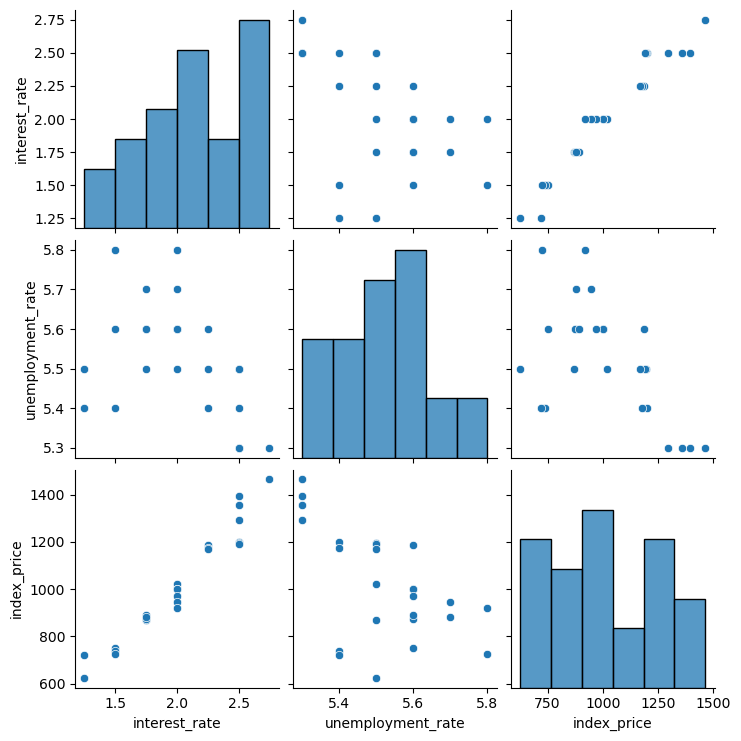

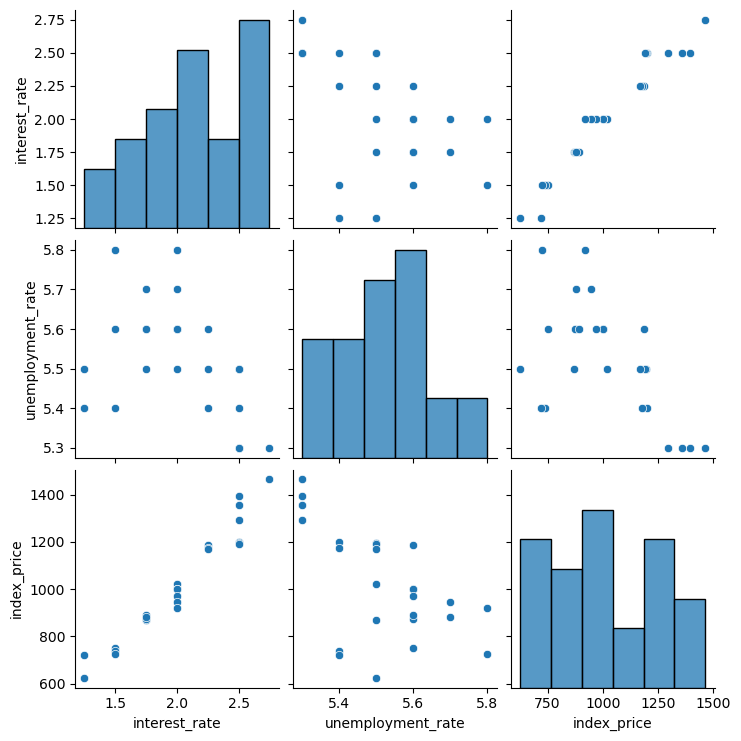

In [12]:
## visualization 
import seaborn as sns
sns.pairplot(df_index)
plt.show()

In [13]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.00000,-0.454670,0.970640
unemployment_rate,-0.45467,1.000000,-0.578351
index_price,0.97064,-0.578351,1.000000


In [15]:
df_index.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1200


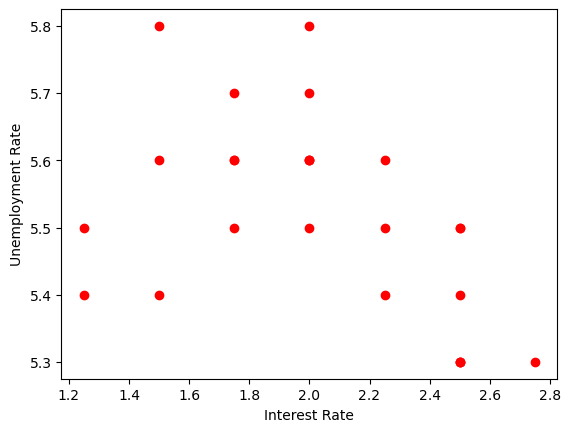

In [19]:
## visualization more closely
plt.scatter(df_index['interest_rate'],df_index['unemployment_rate'], color='r')
plt.xlabel('Interest Rate')
plt.ylabel('Unemployment Rate')
plt.show()

In [20]:
## independent and dependent features

In [21]:
x=df_index[['interest_rate','unemployment_rate']]
## another method df_index.iloc[:,:-1]
y=df_index['index_price'] ## another method df_index.iloc[:,-1]

In [22]:
x.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [23]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.50)

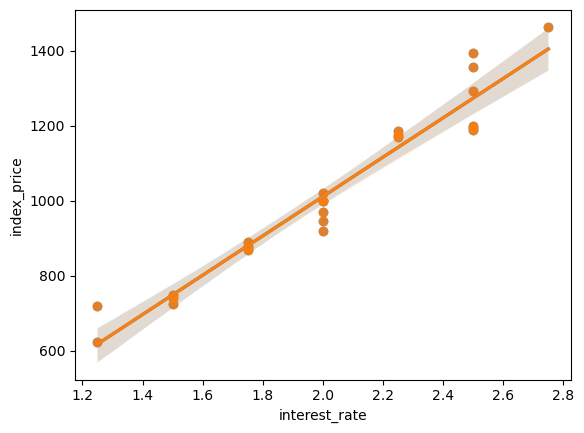

In [31]:
sns.regplot(x=df_index['interest_rate'],y=df_index['index_price'])
plt.show()

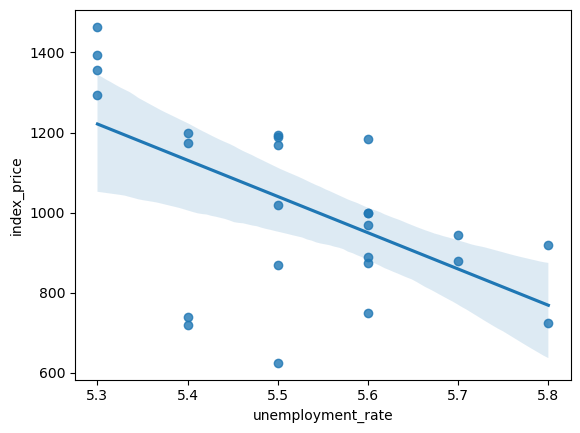

In [33]:
sns.regplot(x=df_index['unemployment_rate'],y=df_index['index_price'])
plt.show()

In [34]:
from sklearn.preprocessing import StandardScaler


In [35]:
scaler=StandardScaler()

In [36]:
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [39]:
from sklearn.linear_model import LinearRegression
reg=LinearRegression(n_jobs=-1)

In [40]:
reg.fit(x_train,y_train)

LinearRegression(n_jobs=-1)

In [42]:
## cross validation technique as a part of testing thee data 
from sklearn.model_selection import cross_val_score
validation_score=cross_val_score(reg,x_train,y_train,scoring='neg_mean_absolute_error', cv=3)

In [44]:
np.mean(validation_score)

np.float64(-39.903994039087195)

In [45]:
## prediction 
y_predict=reg.predict(x_test)
y_predict

array([ 966.73517382, 1320.92331288,  690.98261759,  644.61451943,
       1268.63292434,  868.07668712,  841.93149284, 1019.02556237,
        743.27300613, 1294.77811861,  868.07668712,  940.58997955,
        992.8803681 ])

In [48]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [52]:
mse=mean_squared_error(y_test,y_predict)
mae=mean_absolute_error(y_test,y_predict)
rmse=np.sqrt(mse)
mse,mae,rmse

(1864.9696343788562, 32.167767815007, np.float64(43.18529419118106))

In [56]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_predict)
score


0.9549278286939266

In [57]:
## adjusted r2 score 
1-(1-score)*(len(y_test)-1)/(len(y_test)-x_test.shape[1]-1)

0.9459133944327118

## assumptions 

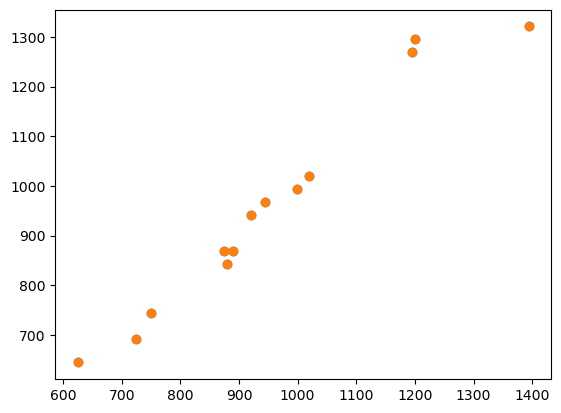

In [59]:
plt.scatter(y_test,y_predict)
plt.show()

In [61]:
residual=y_test-y_predict
residual

14   -21.735174
1     73.076687
22    34.017382
24   -19.614519
5    -73.632924
17     6.923313
19    38.068507
10     0.974438
20     6.726994
4    -94.778119
18    21.923313
15   -20.589980
12     6.119632
Name: index_price, dtype: float64

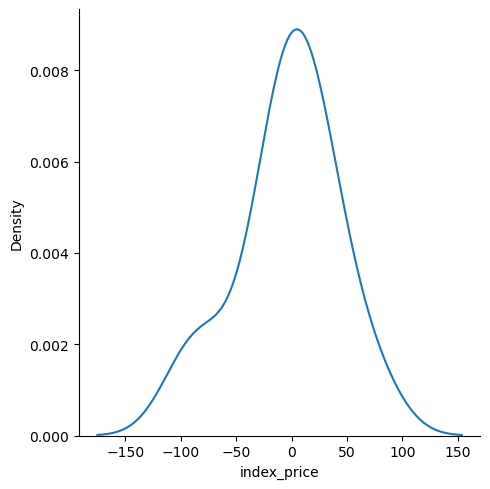

In [65]:
sns.displot(residual,kind='kde')
plt.show()

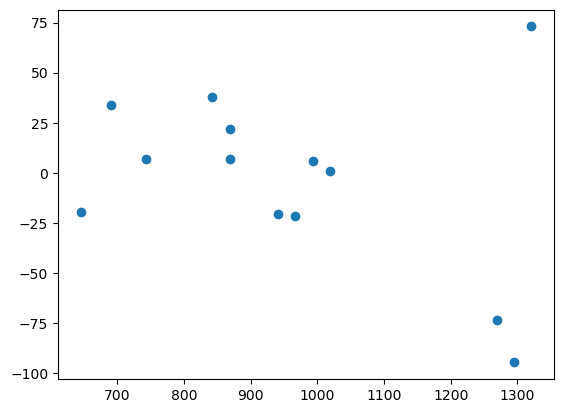

In [66]:
# scatter plot with prediction and residuals
plt.scatter(y_predict,residual)
plt.show()

In [67]:
reg.coef_

array([213.1428624 , -29.23121584])

In [68]:
reg.intercept_

np.float64(1094.5000000000002)